# Falcon Challenge A — Escalamiento a IBM Quantum / Qiskit Runtime ≤ 30 qubits

Este cuaderno prepara el problema de operación del embalse Falcon para ejecutarse en **IBM Quantum** usando **Qiskit Runtime**.

La idea central es:

1. Resolver el horizonte oficial con **programación dinámica exacta (DP)** para obtener un validador clásico.
2. Transformar el problema discreto a **QUBO** por bloques.
3. Codificar cada bloque con **domain-wall** para respetar el límite de qubits:
   \[
   L=5 \Rightarrow L-1=4\text{ qubits por semana}
   \]
4. Usar bloques de hasta **7 semanas**:
   \[
   7\times 4=28\text{ qubits} \leq 30
   \]
5. Enviar cada bloque a **IBM Qiskit Runtime SamplerV2** o ejecutarlo localmente con Aer.

> **Importante:** La DP exacta no se “sube” directamente al procesador cuántico. DP sirve como validador y como referencia de factibilidad. Lo que se ejecuta en IBM Quantum es el QUBO/QAOA por bloques, porque los QPU de compuertas resuelven circuitos parametrizados, no tablas DP.

## 0. Instalación

Ejecuta esta celda en Google Colab o en el servidor donde correrás Qiskit. En IBM Quantum Lab normalmente ya existen varias dependencias, pero se recomienda validar versiones.

In [49]:
# En Colab o servidor limpio:
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime scipy pandas matplotlib

import sys, os, glob, json, time, math, warnings
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 1. Configuración del challenge y del hardware

Parámetros oficiales usados:

- Horizonte oficial: `T=26` semanas.
- Niveles oficiales: `L=5`, con ajustes \(u(t)\in\{-2\Delta u,-\Delta u,0,\Delta u,2\Delta u\}\).
- Restricción de balance acumulado: \(\eta=0.10\).
- Límite cuántico operativo: `MAX_QUBITS=30`.
- Codificación domain-wall: `L-1=4` qubits por semana.

In [50]:
T_OFFICIAL = 26
L_OFFICIAL = 5
ETA_OFFICIAL = 0.10
MAX_QUBITS = 30
QUBITS_PER_WEEK = L_OFFICIAL - 1
MAX_WEEKS_PER_BLOCK = MAX_QUBITS // QUBITS_PER_WEEK

# Por seguridad se deja en 7 semanas: 7*4 = 28 qubits.
BLOCK_SIZE = min(7, MAX_WEEKS_PER_BLOCK)

print("T oficial:", T_OFFICIAL)
print("L oficial:", L_OFFICIAL)
print("Qubits por semana con domain-wall:", QUBITS_PER_WEEK)
print("Semanas máximas por bloque:", MAX_WEEKS_PER_BLOCK)
print("Bloque usado:", BLOCK_SIZE, "semanas")
print("Qubits por bloque:", BLOCK_SIZE * QUBITS_PER_WEEK)

T oficial: 26
L oficial: 5
Qubits por semana con domain-wall: 4
Semanas máximas por bloque: 7
Bloque usado: 7 semanas
Qubits por bloque: 28


## 2. Conexión con IBM Quantum Runtime

La celda siguiente está preparada para correr en IBM Quantum. No escribas el token directamente en el cuaderno si lo vas a compartir; usa una variable de entorno.

### Opciones recomendadas

- `EXECUTE_IBM = False`: construye circuitos y corre simulación/local sin enviar al QPU.
- `EXECUTE_IBM = True`: envía circuitos a IBM Quantum Runtime.

Para ejecutar en QPU real:

```python
os.environ["IBM_QUANTUM_TOKEN"] = "tu_token"
EXECUTE_IBM = True
```

In [51]:
EXECUTE_IBM = True

In [52]:
from google.colab import userdata
crn = userdata.get('CRN')
token = userdata.get('APIKEY')

In [56]:
EXECUTE_IBM = True       # Cambia a True para enviar a IBM Quantum.
USE_LOCAL_AER = True      # Simulación local para validar circuitos pequeños.
IBM_INSTANCE = None       # Ejemplo: "hub/group/project" si tu cuenta lo requiere.
IBM_CHANNEL = "ibm_quantum_platform"  # Canal actual de IBM Quantum Platform.

backend = None
service = None

if EXECUTE_IBM:
    from qiskit_ibm_runtime import QiskitRuntimeService
    if token:
        QiskitRuntimeService.save_account(
            channel=IBM_CHANNEL,
            token=token,
            instance=crn,
            overwrite=True
        )
    service = QiskitRuntimeService(channel=IBM_CHANNEL, instance=IBM_INSTANCE)
    # Fetch all operational, non-simulator backends
    all_backends = service.backends(
        operational=True,
        simulator=False
    )
    # Filter them to only include those with enough qubits
    candidates = [
        b for b in all_backends if b.num_qubits >= MAX_QUBITS
    ]
    if not candidates:
        raise RuntimeError("No se encontraron backends IBM que cumplan los criterios.")

    # Then find the least busy among these already filtered candidates
    # Manually select the least busy backend from the 'candidates' list
    least_busy_candidate = min(candidates, key=lambda b: b.status().pending_jobs)
    backend = least_busy_candidate

    print("Backend IBM seleccionado:", backend.name)
    print("Qubits backend:", backend.num_qubits)
else:
    print("Modo sin envío a IBM. Se construirán los circuitos y se validará localmente cuando sea posible.")

Backend IBM seleccionado: ibm_fez
Qubits backend: 156


## 3. Carga de datos IBWC y constantes del embalse

El cuaderno busca automáticamente los archivos descargados del challenge:

- `Discharge.Best Available@08461300...csv`: liberación histórica observada.
- `Total Storage.Web-Daily...csv`: almacenamiento observado.
- `falcon_reservoir_constants.json`: capacidad y umbral crítico.

Si corres en Colab, sube los archivos al entorno o monta Google Drive.

In [57]:
DATA_DIR_CANDIDATES = ["/content", "/mnt/data", ".", "./data"]

RUN_FILE_UPLOAD = True
if RUN_FILE_UPLOAD:
    from google.colab import files
    uploaded = files.upload()

def find_file(pattern):
    for d in DATA_DIR_CANDIDATES:
        matches = sorted(glob.glob(os.path.join(d, pattern)))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"No encontré {pattern}. Sube el archivo o ajusta DATA_DIR_CANDIDATES.")

def read_ibwc_csv(path, value_name):
    raw = pd.read_csv(path, header=None)
    df = raw.iloc[1:].copy()
    df.columns = ["timestamp", value_name]
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    df = df.dropna(subset=["timestamp", value_name]).sort_values("timestamp")
    return df.set_index("timestamp")[[value_name]]

def integrate_discharge_to_weekly_volume(flow_df):
    """Convierte m3/s a volumen semanal m3 usando integración por intervalos observados."""
    df = flow_df.sort_index().copy()
    col = df.columns[0]
    idx = df.index.to_series()
    med = idx.diff().median()
    if pd.isna(med) or med <= pd.Timedelta(0):
        med = pd.Timedelta(minutes=15)
    next_idx = idx.shift(-1)
    seconds = (next_idx - idx).dt.total_seconds().fillna(med.total_seconds())
    seconds = seconds.clip(lower=0, upper=3*med.total_seconds())
    volume = df[col].to_numpy() * seconds.to_numpy()
    return pd.DataFrame({"Robs_m3": volume}, index=df.index).resample("W-SUN").sum()

def prepare_weekly_instance(T=T_OFFICIAL, start_date=None):
    discharge_path = find_file("*Discharge.Best Available@08461300*.csv")
    storage_path = find_file("*Total Storage.Web-Daily*.csv")
    constants_path = find_file("falcon_reservoir_constants.json")

    flow = read_ibwc_csv(discharge_path, "flow_m3s")
    storage = read_ibwc_csv(storage_path, "Sobs_m3")
    weekly_R = integrate_discharge_to_weekly_volume(flow)
    weekly_S = storage.resample("W-SUN").last()
    weekly = weekly_R.join(weekly_S, how="inner").dropna()
    if start_date is not None:
        weekly = weekly.loc[pd.to_datetime(start_date):]
    if len(weekly) < T+1:
        raise ValueError(f"Se requieren al menos {T+1} semanas; hay {len(weekly)}.")
    weekly = weekly.iloc[:T+1].copy()

    Robs = weekly["Robs_m3"].iloc[:T].to_numpy(float)
    Sobs = weekly["Sobs_m3"].iloc[:T+1].to_numpy(float)
    dates = weekly.index[:T+1]
    constants = json.load(open(constants_path, encoding="utf-8"))
    smax = float(constants["s_max_m3"])
    smin = float(constants.get("s_min_m3", 0.25*smax))
    return Robs, Sobs, dates, smin, smax

Robs, Sobs, dates, S_MIN, S_MAX = prepare_weekly_instance(T_OFFICIAL)
print("Semanas T:", len(Robs))
print("Ventana:", dates[0].date(), "a", dates[-1].date())
print("Smax m3:", f"{S_MAX:,.0f}")
print("Smin m3:", f"{S_MIN:,.0f}")

Saving DataSetExport-Discharge.Best Available@08461300-Instantaneous-m^3 s-20260629185451.csv to DataSetExport-Discharge.Best Available@08461300-Instantaneous-m^3 s-20260629185451 (3).csv
Saving DataSetExport-Lake Area.Best Available@08461200-Instantaneous-m^2-20260629185344.csv to DataSetExport-Lake Area.Best Available@08461200-Instantaneous-m^2-20260629185344 (3).csv
Saving DataSetExport-Percentage.Conservation-Web-Telemetry@08461200-Instantaneous-%-20260630094142.csv to DataSetExport-Percentage.Conservation-Web-Telemetry@08461200-Instantaneous-%-20260630094142 (3).csv
Saving DataSetExport-Reservoir Elevation.Web-Daily-m@08461200-Instantaneous-m-20260629185508.csv to DataSetExport-Reservoir Elevation.Web-Daily-m@08461200-Instantaneous-m-20260629185508 (3).csv
Saving DataSetExport-Total Storage.Web-Daily-tcm@08461200-Instantaneous-m^3-20260629185416.csv to DataSetExport-Total Storage.Web-Daily-tcm@08461200-Instantaneous-m^3-20260629185416 (3).csv
Saving falcon_download_manifest.json t

## 4. Métrica oficial, restricciones y niveles discretos

El modelo usa:

\[
S_{opt}(t+1)=S_{opt}(t)+\Delta S_{obs}(t)-u(t)
\]

La implementación usa la serie observada de almacenamiento para reconstruir:

\[
S_{opt}(t)=S_{obs}(t)-\sum_{\tau < t}u(\tau)
\]

Luego evalúa:

\[
SRS=-(w_1C_{crit}+w_2C_{dev}+w_3C_{smooth})
\]

In [58]:
def levels_for_L(L):
    if L % 2 != 1:
        raise ValueError("Este cuaderno usa L impar para centrar niveles en cero.")
    return np.arange(-(L//2), L//2 + 1, dtype=int)

def official_weights(T, smin, umax):
    w1 = 1.0 / ((T+1)*smin**2)
    w2 = 0.1 / (T*umax**2) if umax > 0 else 0.0
    w3 = 0.1 / ((T-1)*(2*umax)**2) if T > 1 and umax > 0 else 0.0
    return w1, w2, w3

def storage_from_u(Sobs, u):
    u = np.asarray(u, float)
    return np.asarray(Sobs, float) - np.concatenate([[0.0], np.cumsum(u)])

def evaluate_policy(u, Robs, Sobs, smin, smax, eta=ETA_OFFICIAL):
    u = np.asarray(u, float)
    Robs = np.asarray(Robs, float)
    T = len(u)
    delta_u = 0.25*np.median(Robs)
    uvals = levels_for_L(L_OFFICIAL)*delta_u
    umax = np.max(np.abs(uvals))
    w1, w2, w3 = official_weights(T, smin, umax)
    Sopt = storage_from_u(Sobs, u)
    R = Robs + u
    Ccrit = np.sum(np.maximum(0, smin - Sopt)**2)
    Cdev = np.sum(u**2)
    Csmooth = np.sum(np.diff(u)**2) if T > 1 else 0.0
    cost = w1*Ccrit + w2*Cdev + w3*Csmooth
    feasible = {
        "release_nonnegative": bool(np.all(R >= -1e-9)),
        "storage_bounds": bool(np.all((Sopt >= -1e-9) & (Sopt <= smax + 1e-9))),
        "balance": bool(abs(np.sum(u)) <= eta*np.sum(Robs) + 1e-9)
    }
    feasible["all"] = all(feasible.values())
    return {
        "SRS": -float(cost),
        "cost": float(cost),
        "Ccrit": float(Ccrit),
        "Cdev": float(Cdev),
        "Csmooth": float(Csmooth),
        "Sopt": Sopt,
        "R": R,
        "u": u,
        "sum_u_m3": float(np.sum(u)),
        "min_storage_pct_cap": float(100*np.min(Sopt)/smax),
        "min_release_m3": float(np.min(R)),
        "feasible": feasible
    }

def threshold_rule(Robs, Sobs, delta_u, smin):
    u = np.zeros(len(Robs))
    Srun = float(Sobs[0])
    for t in range(len(Robs)):
        u[t] = -delta_u if Srun < smin else 0.0
        Srun = Srun + (Sobs[t+1]-Sobs[t]) - u[t]
    return u

delta_u = 0.25*np.median(Robs)
u_levels = levels_for_L(L_OFFICIAL)*delta_u
print("Delta u m3/semana:", f"{delta_u:,.0f}")
print("Niveles k:", levels_for_L(L_OFFICIAL).tolist())
print("Niveles u:", [round(x,2) for x in u_levels])

Delta u m3/semana: 2,706,476
Niveles k: [-2, -1, 0, 1, 2]
Niveles u: [np.float64(-5412952.42), np.float64(-2706476.21), np.float64(0.0), np.float64(2706476.21), np.float64(5412952.42)]


## 5. DP exacta: validador clásico del horizonte oficial

La DP exacta explora los niveles discretos sin enumerar \(L^T\) trayectorias completas. Guarda estados por:

- semana,
- balance acumulado \(\sum k_t\),
- nivel previo para evaluar suavidad.

El resultado se usa como **referencia** para evaluar si el QUBO/QAOA recupera una política razonable.

In [59]:
def dp_exact_optimize(Robs, Sobs, L, smin, smax, eta=ETA_OFFICIAL, delta_u=None):
    T = len(Robs)
    levels = levels_for_L(L)
    if delta_u is None:
        delta_u = 0.25*np.median(Robs)
    uvals = levels*delta_u
    umax = np.max(np.abs(uvals))
    w1, w2, w3 = official_weights(T, smin, umax)
    bal_units = int(np.floor(eta*np.sum(Robs)/delta_u + 1e-12))
    min_k, max_k = int(levels.min()), int(levels.max())
    states = {(0, None): (w1*max(0.0, smin - Sobs[0])**2, [])}
    state_counts = []
    for t in range(T):
        new_states = {}
        rem = T - t - 1
        for (cum_k, prev_idx), (cost, path) in states.items():
            for idx, k in enumerate(levels):
                u = float(uvals[idx])
                if Robs[t] + u < -1e-9:
                    continue
                new_cum = int(cum_k + k)
                if new_cum + rem*min_k > bal_units:
                    continue
                if new_cum + rem*max_k < -bal_units:
                    continue
                S_next = float(Sobs[t+1] - delta_u*new_cum)
                if S_next < -1e-9 or S_next > smax + 1e-9:
                    continue
                add = w1*max(0.0, smin - S_next)**2 + w2*u**2
                if prev_idx is not None:
                    add += w3*(u - float(uvals[prev_idx]))**2
                key = (new_cum, idx)
                candidate = (cost + add, path + [int(k)])
                if key not in new_states or candidate[0] < new_states[key][0]:
                    new_states[key] = candidate
        states = new_states
        state_counts.append(len(states))
        if not states:
            raise RuntimeError(f"DP sin estados factibles en t={t}")
    best_key, (best_cost, best_path) = min(states.items(), key=lambda kv: kv[1][0])
    k = np.array(best_path, dtype=int)
    u = k*delta_u
    out = evaluate_policy(u, Robs, Sobs, smin, smax, eta)
    out["k"] = k
    out["state_counts"] = state_counts
    return out

u_hist = np.zeros(T_OFFICIAL)
u_rule = threshold_rule(Robs, Sobs, delta_u, S_MIN)

t0 = time.time()
dp = dp_exact_optimize(Robs, Sobs, L_OFFICIAL, S_MIN, S_MAX, ETA_OFFICIAL, delta_u)
dp_runtime = time.time() - t0

rows = []
for name, u in [("Histórico", u_hist), ("Regla umbral", u_rule), ("DP exacta", dp["u"])]:
    ev = evaluate_policy(u, Robs, Sobs, S_MIN, S_MAX)
    rows.append({
        "modelo": name,
        "SRS": ev["SRS"],
        "Ccrit": ev["Ccrit"],
        "Cdev": ev["Cdev"],
        "Csmooth": ev["Csmooth"],
        "sum_u_m3": ev["sum_u_m3"],
        "min_storage_pct_cap": ev["min_storage_pct_cap"],
        "factible": ev["feasible"]["all"],
        "runtime_s": dp_runtime if name == "DP exacta" else 0.0
    })
summary_df = pd.DataFrame(rows)
display(summary_df)
print("k_DP:", dp["k"].tolist())

,modelo,SRS,Ccrit,Cdev,Csmooth,sum_u_m3,min_storage_pct_cap,factible,runtime_s
0,Histórico,-0.311534,5.685972e+18,0.000000e+00,0.000000e+00,0.000000e+00,9.653041,True,0.000000
1,Regla umbral,-0.290505,4.845873e+18,1.904504e+14,0.000000e+00,-7.036838e+07,11.298953,False,0.000000
2,DP exacta,-0.293160,5.148445e+18,8.057515e+13,1.465003e+13,-2.977124e+07,10.558293,True,0.049052


k_DP: [0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 6. Segmentación para IBM Quantum

Para respetar 30 qubits:

\[
\text{qubits por bloque}=B(L-1)
\]

Con \(L=5\), cada semana requiere 4 qubits. Por tanto:

\[
B=7\Rightarrow 28\text{ qubits}
\]

El horizonte oficial de 26 semanas se divide como:

\[
7+7+7+5
\]

In [60]:
def make_blocks(T, block_size=BLOCK_SIZE):
    blocks = []
    start = 0
    block_id = 0
    while start < T:
        end = min(T, start + block_size)
        B = end - start
        blocks.append({
            "block_id": block_id,
            "start_week": start,
            "end_week_exclusive": end,
            "weeks": B,
            "qubits_domain_wall": B*(L_OFFICIAL-1)
        })
        block_id += 1
        start = end
    return blocks

blocks = make_blocks(T_OFFICIAL)
blocks_df = pd.DataFrame(blocks)
display(blocks_df)
assert blocks_df["qubits_domain_wall"].max() <= MAX_QUBITS

,block_id,start_week,end_week_exclusive,weeks,qubits_domain_wall
0,0,0,7,7,28
1,1,7,14,7,28
2,2,14,21,7,28
3,3,21,26,5,20


## 7. Construcción QUBO por bloque

### Codificación domain-wall

Para cada semana local \(t\), se usan 4 variables binarias:

\[
y_{t,0},y_{t,1},y_{t,2},y_{t,3}\in\{0,1\}
\]

El índice de nivel se obtiene como:

\[
\ell_t=\sum_{r=0}^{3}y_{t,r}
\]

El nivel discreto oficial es:

\[
k_t=\ell_t-2\in\{-2,-1,0,1,2\}
\]

La penalización domain-wall evita cadenas inválidas tipo `0101`:

\[
P_{dw}\sum_{t,r} y_{t,r+1}(1-y_{t,r})
\]

### Componentes del QUBO

El QUBO por bloque aproxima el objetivo oficial con:

1. penalización de almacenamiento crítico activa cerca de \(S_{min}\),
2. desviación \(u_t^2\),
3. suavidad \((u_t-u_{t-1})^2\),
4. penalización domain-wall,
5. penalización de balance local anclada al balance DP del bloque.

El anclaje DP no reemplaza al QAOA: ayuda a que cada bloque respete factibilidad global sin exceder 30 qubits.

In [61]:
class QUBOBuilder:
    def __init__(self):
        self.linear = defaultdict(float)
        self.quad = defaultdict(float)
        self.offset = 0.0
    def add_linear(self, i, c):
        self.linear[int(i)] += float(c)
    def add_quadratic(self, i, j, c):
        i, j = int(i), int(j)
        if i == j:
            self.add_linear(i, c)
        else:
            if i > j:
                i, j = j, i
            self.quad[(i, j)] += float(c)
    def add_square(self, expr, weight=1.0, const=0.0):
        # weight*(const + sum a_i x_i)^2
        self.offset += weight*const*const
        items = list(expr.items())
        for i, ai in items:
            self.add_linear(i, weight*(2*const*ai + ai*ai))
        for a in range(len(items)):
            i, ai = items[a]
            for b in range(a+1, len(items)):
                j, aj = items[b]
                self.add_quadratic(i, j, weight*2*ai*aj)
    def to_dict(self):
        return {
            "linear": dict(self.linear),
            "quadratic": dict(self.quad),
            "offset": float(self.offset)
        }

@dataclass
class BlockQUBO:
    block_id: int
    start: int
    end: int
    n_weeks: int
    n_qubits: int
    qubo: dict
    variable_names: list
    target_sum_k: int
    prev_k: int


def var_index(local_t, r, L=L_OFFICIAL):
    return local_t*(L-1) + r

def k_expr_for_week(local_t, L=L_OFFICIAL):
    # k_t = sum_r y_{t,r} - 2
    expr = {var_index(local_t, r, L): 1.0 for r in range(L-1)}
    const = -(L//2)
    return expr, const

def add_expr_square(builder, terms, const, weight):
    builder.add_square(terms, weight=weight, const=const)

def build_block_qubo(block, Robs, Sobs, smin, smax, delta_u, dp_k=None,
                     penalty_dw=8.0, penalty_balance=0.20, storage_margin=1.10):
    """Construye QUBO por bloque con variables domain-wall.
    Los pesos están normalizados para estabilidad numérica en QAOA.
    """
    start, end = block["start_week"], block["end_week_exclusive"]
    B = end - start
    n = B*(L_OFFICIAL-1)
    builder = QUBOBuilder()
    levels = levels_for_L(L_OFFICIAL)
    uvals = levels*delta_u
    umax = np.max(np.abs(uvals))
    w1, w2, w3 = official_weights(T_OFFICIAL, smin, umax)

    # Normalización adicional para que los coeficientes QUBO no sean gigantes.
    # Esta escala conserva el orden relativo y mejora ángulos de QAOA.
    scale = 1.0

    # 1) Domain-wall: y_{r+1}(1-y_r)
    for lt in range(B):
        for r in range(L_OFFICIAL-2):
            y_r = var_index(lt, r)
            y_next = var_index(lt, r+1)
            builder.add_linear(y_next, penalty_dw)
            builder.add_quadratic(y_r, y_next, -penalty_dw)

    # 2) Desviación: u_t^2 = delta_u^2*k_t^2
    for lt in range(B):
        expr, const = k_expr_for_week(lt)
        add_expr_square(builder, expr, const, scale*w2*delta_u**2)

    # 3) Suavidad: (u_t-u_{t-1})^2
    for lt in range(B):
        expr_t, const_t = k_expr_for_week(lt)
        if lt == 0:
            prev_k = int(dp_k[start-1]) if (dp_k is not None and start > 0) else 0
            expr = dict(expr_t)
            const = const_t - prev_k
        else:
            expr_prev, const_prev = k_expr_for_week(lt-1)
            expr = dict(expr_t)
            for i, c in expr_prev.items():
                expr[i] = expr.get(i, 0.0) - c
            const = const_t - const_prev
        add_expr_square(builder, expr, const, scale*w3*delta_u**2)

    # 4) Riesgo de almacenamiento crítico activo cerca del umbral.
    # Sopt local aprox = Sobs[start+tau] - delta_u*(sum k prev global + sum k local previo)
    # Se activa cuando la trayectoria observada está cerca/debajo del umbral.
    global_prev_sum_k = int(np.sum(dp_k[:start])) if dp_k is not None else 0
    for tau in range(1, B+1):
        global_week = start + tau
        base_deficit = smin - (Sobs[global_week] - delta_u*global_prev_sum_k)
        active = (Sobs[global_week] <= storage_margin*smin) or (base_deficit > 0)
        if not active:
            continue
        expr = {}
        # deficit = smin - Sobs + delta_u*(global_prev_sum_k + sum local k up to tau-1)
        const = base_deficit
        for lt in range(tau):
            e, c = k_expr_for_week(lt)
            const += delta_u*c
            for i, coef in e.items():
                expr[i] = expr.get(i, 0.0) + delta_u*coef
        add_expr_square(builder, expr, const, scale*w1)

    # 5) Balance local anclado a DP: evita que cada bloque abuse de reducir liberaciones.
    if dp_k is not None:
        target_sum_k = int(np.sum(dp_k[start:end]))
    else:
        target_sum_k = 0
    expr = {}
    const = -target_sum_k
    for lt in range(B):
        e, c = k_expr_for_week(lt)
        const += c
        for i, coef in e.items():
            expr[i] = expr.get(i, 0.0) + coef
    add_expr_square(builder, expr, const, penalty_balance)

    names = [f"b{block['block_id']}_t{start+lt}_y{r}" for lt in range(B) for r in range(L_OFFICIAL-1)]
    return BlockQUBO(
        block_id=block["block_id"],
        start=start,
        end=end,
        n_weeks=B,
        n_qubits=n,
        qubo=builder.to_dict(),
        variable_names=names,
        target_sum_k=target_sum_k,
        prev_k=int(dp_k[start-1]) if (dp_k is not None and start > 0) else 0
    )

block_qubos = [build_block_qubo(b, Robs, Sobs, S_MIN, S_MAX, delta_u, dp_k=dp["k"]) for b in blocks]
qubo_overview = pd.DataFrame([{
    "block_id": q.block_id,
    "weeks": q.n_weeks,
    "qubits": q.n_qubits,
    "linear_terms": len(q.qubo["linear"]),
    "quadratic_terms": len(q.qubo["quadratic"]),
    "target_sum_k_DP": q.target_sum_k
} for q in block_qubos])
display(qubo_overview)

,block_id,weeks,qubits,linear_terms,quadratic_terms,target_sum_k_DP
0,0,7,28,28,378,-6
1,1,7,28,28,378,-5
2,2,7,28,28,378,0
3,3,5,20,20,190,0


## 8. Decodificación de bitstrings y validación post-QPU

IBM devuelve bitstrings muestreados. Cada bitstring se traduce a niveles semanales:

\[
\ell_t=\sum_r y_{t,r},\quad k_t=\ell_t-2,\quad u_t=k_t\Delta u
\]

Se aplica una reparación simple de domain-wall: si una cadena no es monótona, se sustituye por la cadena válida más cercana.

In [62]:
def repair_domain_wall(bits_week):
    bits = np.array(bits_week, dtype=int)
    # El índice se estima por suma y se reconstruye como 111..000 válido.
    idx = int(np.clip(np.round(bits.sum()), 0, L_OFFICIAL-1))
    repaired = np.array([1 if r < idx else 0 for r in range(L_OFFICIAL-1)], dtype=int)
    return repaired

def decode_block_bitstring(bitstring, block_qubo):
    # Qiskit puede devolver orden little-endian. Este helper asume bitstring visual izquierda-derecha.
    # Se recomienda validar con REVERSE_BIT_ORDER según backend/respuesta.
    s = bitstring.replace(" ", "")
    if len(s) != block_qubo.n_qubits:
        raise ValueError(f"Bitstring de longitud {len(s)}; se esperaban {block_qubo.n_qubits}")
    bits = np.array([int(ch) for ch in s], dtype=int)
    k_list, repaired_bits = [], []
    for lt in range(block_qubo.n_weeks):
        chunk = bits[lt*(L_OFFICIAL-1):(lt+1)*(L_OFFICIAL-1)]
        rep = repair_domain_wall(chunk)
        idx = int(rep.sum())
        k = idx - (L_OFFICIAL//2)
        k_list.append(k)
        repaired_bits.extend(rep.tolist())
    return np.array(k_list, dtype=int), "".join(map(str, repaired_bits))

def qubo_energy_from_bits(bits, qubo):
    x = np.array(bits, dtype=int)
    E = qubo.get("offset", 0.0)
    for i, c in qubo["linear"].items():
        E += c*x[int(i)]
    for (i, j), c in qubo["quadratic"].items():
        E += c*x[int(i)]*x[int(j)]
    return float(E)

def brute_force_small_qubo(block_qubo, max_qubits=20):
    """Solo para depuración. 28 qubits no debe brute-forcearse."""
    n = block_qubo.n_qubits
    if n > max_qubits:
        return None
    best = (np.inf, None)
    for mask in range(1 << n):
        bits = [(mask >> (n-1-i)) & 1 for i in range(n)]
        E = qubo_energy_from_bits(bits, block_qubo.qubo)
        if E < best[0]:
            best = (E, "".join(map(str,bits)))
    k, repaired = decode_block_bitstring(best[1], block_qubo)
    return {"energy": best[0], "bitstring": best[1], "repaired": repaired, "k": k}

# Prueba de decodificación con el patrón DP objetivo de cada bloque.
def encode_k_domain_wall(k_list):
    bits = []
    for k in k_list:
        idx = int(k + L_OFFICIAL//2)
        bits.extend([1 if r < idx else 0 for r in range(L_OFFICIAL-1)])
    return "".join(map(str, bits))

for q in block_qubos:
    target_bits = encode_k_domain_wall(dp["k"][q.start:q.end])
    target_energy = qubo_energy_from_bits([int(c) for c in target_bits], q.qubo)
    print(f"Bloque {q.block_id}: bits={len(target_bits)}, energía_DP_codificada={target_energy:.6g}")

Bloque 0: bits=28, energía_DP_codificada=0.0758668
Bloque 1: bits=28, energía_DP_codificada=0.0771668
Bloque 2: bits=28, energía_DP_codificada=0.0780793
Bloque 3: bits=20, energía_DP_codificada=0.0511204


## 9. Construcción de circuitos QAOA para IBM

Se usa un circuito QAOA básico:

1. Estado inicial: Hadamard en todos los qubits.
2. Separador de fase QUBO:
   - término lineal \(a_i x_i\): compuerta de fase `p(-γ a_i)`.
   - término cuadrático \(b_{ij}x_ix_j\): compuerta `cp(-γ b_ij)`.
3. Mezclador: `rx(2β)`.
4. Medición de todos los qubits.

Para QPU real, se transpila con `generate_preset_pass_manager` sobre el backend seleccionado.

In [63]:
def normalize_qubo_for_angles(qubo, clip=3.0):
    """Escala coeficientes para que los ángulos QAOA sean numéricamente manejables."""
    vals = [abs(v) for v in qubo["linear"].values()] + [abs(v) for v in qubo["quadratic"].values()]
    scale = max(vals) if vals else 1.0
    scale = max(scale, 1e-12)
    out = {
        "linear": {i: float(np.clip(c/scale, -clip, clip)) for i, c in qubo["linear"].items()},
        "quadratic": {ij: float(np.clip(c/scale, -clip, clip)) for ij, c in qubo["quadratic"].items()},
        "offset": float(qubo.get("offset", 0.0)/scale),
        "scale": float(scale)
    }
    return out

def build_qaoa_circuit_from_qubo(block_qubo, gammas, betas, measure=True):
    from qiskit import QuantumCircuit
    n = block_qubo.n_qubits
    q = normalize_qubo_for_angles(block_qubo.qubo)
    qc = QuantumCircuit(n, n if measure else 0)
    qc.h(range(n))
    for gamma, beta in zip(gammas, betas):
        for i, c in q["linear"].items():
            qc.p(-float(gamma)*float(c), int(i))
        for (i, j), c in q["quadratic"].items():
            qc.cp(-float(gamma)*float(c), int(i), int(j))
        for i in range(n):
            qc.rx(2*float(beta), i)
    if measure:
        qc.measure(range(n), range(n))
    return qc

# Parámetros iniciales conservadores para QAOA p=1 y p=2.
QAOA_P = 1
gammas = [0.8]
betas = [0.35]

circuits = []
for q in block_qubos:
    qc = build_qaoa_circuit_from_qubo(q, gammas, betas, measure=True)
    circuits.append(qc)
    print(f"Bloque {q.block_id}: qubits={q.n_qubits}, depth bruto={qc.depth()}, gates={qc.count_ops()}")

Bloque 0: qubits=28, depth bruto=60, gates=OrderedDict({'cp': 378, 'h': 28, 'p': 28, 'rx': 28, 'measure': 28})
Bloque 1: qubits=28, depth bruto=60, gates=OrderedDict({'cp': 378, 'h': 28, 'p': 28, 'rx': 28, 'measure': 28})
Bloque 2: qubits=28, depth bruto=60, gates=OrderedDict({'cp': 378, 'h': 28, 'p': 28, 'rx': 28, 'measure': 28})
Bloque 3: qubits=20, depth bruto=44, gates=OrderedDict({'cp': 190, 'h': 20, 'p': 20, 'rx': 20, 'measure': 20})


## 10. Simulación local opcional

La simulación exacta de 28 qubits puede ser muy pesada. Por eso:

- bloques de 5 semanas o menos pueden simularse con Aer en máquina razonable,
- bloques de 7 semanas se recomiendan para IBM Runtime o para simuladores con recursos suficientes.

Esta celda intenta usar `qiskit-aer` si está instalado.

In [64]:
def get_counts_from_sampler_result(result, index=0):
    """Extrae counts de SamplerV2 o de resultados tipo Aer, con tolerancia a cambios de API."""
    item = result[index] if hasattr(result, "__getitem__") else result
    # SamplerV2: item.data.<classical_register>.get_counts()
    try:
        data = item.data
        # Nombre típico si el circuito tiene ClassicalRegister default: c
        for attr in ["c", "meas"]:
            if hasattr(data, attr):
                return getattr(data, attr).get_counts()
        # Toma el primer registro disponible
        for name in dir(data):
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                return obj.get_counts()
    except Exception:
        pass
    # Aer backend legacy
    try:
        return result.get_counts(index)
    except Exception:
        pass
    raise ValueError("No pude extraer counts del resultado. Revisa la versión de Qiskit Runtime.")

def run_local_sampler_if_possible(circuit, shots=1024):
    try:
        from qiskit_aer.primitives import SamplerV2 as AerSampler
        sampler = AerSampler()
        job = sampler.run([circuit], shots=shots)
        return job.result()
    except Exception as e:
        print("No se pudo usar Aer SamplerV2:", repr(e))
        return None

local_results = []
if USE_LOCAL_AER:
    for q, qc in zip(block_qubos, circuits):
        if q.n_qubits <= 20:  # evitar simulación pesada accidental
            print("Simulando bloque", q.block_id)
            res = run_local_sampler_if_possible(qc, shots=2048)
            if res is not None:
                counts = get_counts_from_sampler_result(res, 0)
                best_bs = max(counts, key=counts.get)
                k_block, repaired = decode_block_bitstring(best_bs, q)
                local_results.append({
                    "block_id": q.block_id,
                    "best_bitstring": best_bs,
                    "shots_best": counts[best_bs],
                    "k_block": k_block.tolist(),
                    "repaired": repaired
                })
        else:
            print(f"Bloque {q.block_id} omitido en Aer local por tamaño: {q.n_qubits} qubits.")
else:
    print("Simulación local desactivada.")

local_results

Bloque 0 omitido en Aer local por tamaño: 28 qubits.
Bloque 1 omitido en Aer local por tamaño: 28 qubits.
Bloque 2 omitido en Aer local por tamaño: 28 qubits.
Simulando bloque 3


[{'block_id': 3,
  'best_bitstring': '10100010101010101001',
  'shots_best': 3,
  'k_block': [0, -1, 0, 0, 0],
  'repaired': '11001000110011001100'}]

## 11. Ejecución en IBM Quantum Runtime

Esta sección envía los circuitos a IBM. Recomendaciones:

- Empezar con `shots=1024` o `shots=2048`.
- Probar primero un bloque de 5 semanas.
- Usar `optimization_level=3` en transpilación.
- Guardar `job_id` para recuperar resultados después.
- Si el backend tiene mucha cola, usar el menos ocupado con al menos 30 qubits.

In [65]:
IBM_SHOTS = 2048
ibm_job_ids = []
ibm_counts_by_block = {}

if EXECUTE_IBM:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import SamplerV2 as Sampler

    # Ajustar tamaño real por backend si se desea:
    if backend.num_qubits < MAX_QUBITS:
        raise RuntimeError("El backend seleccionado no tiene suficientes qubits para el bloque objetivo.")

    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    isa_circuits = []
    for q, qc in zip(block_qubos, circuits):
        tqc = pm.run(qc)
        isa_circuits.append(tqc)
        print(f"Bloque {q.block_id}: depth ISA={tqc.depth()}, gates={tqc.count_ops()}")

    sampler = Sampler(mode=backend)
    job = sampler.run(isa_circuits, shots=IBM_SHOTS)
    print("IBM job_id:", job.job_id())
    ibm_job_ids.append(job.job_id())

    result = job.result()
    for idx, q in enumerate(block_qubos):
        counts = get_counts_from_sampler_result(result, idx)
        ibm_counts_by_block[q.block_id] = counts
        print("Bloque", q.block_id, "top bitstring:", max(counts, key=counts.get))
else:
    print("EXECUTE_IBM=False. No se envió trabajo a IBM Quantum.")

Bloque 0: depth ISA=1731, gates=OrderedDict({'sx': 4461, 'rz': 2133, 'cz': 2112, 'x': 37, 'measure': 28})
Bloque 1: depth ISA=2133, gates=OrderedDict({'sx': 4464, 'cz': 2135, 'rz': 1996, 'x': 31, 'measure': 28})
Bloque 2: depth ISA=1793, gates=OrderedDict({'sx': 4497, 'cz': 2142, 'rz': 2066, 'x': 48, 'measure': 28})
Bloque 3: depth ISA=1132, gates=OrderedDict({'sx': 2062, 'rz': 1041, 'cz': 968, 'x': 30, 'measure': 20})
IBM job_id: d92j4vd958jc73brsfg0
Bloque 0 top bitstring: 0111010010101000001000000110
Bloque 1 top bitstring: 0110000000000000001010110011
Bloque 2 top bitstring: 0101010100010000010110000010
Bloque 3 top bitstring: 11111001011100000110


## 12. Reconstrucción de política semanal desde resultados IBM

Cuando IBM devuelva counts, se toma el bitstring con más frecuencia por bloque, se decodifica, se repara si es necesario y se reconstruye la política completa.

Después se evalúa con la métrica oficial SRS para comparar contra DP.

In [66]:
def reconstruct_policy_from_counts(counts_by_block, block_qubos, reverse_bit_order=False):
    k_all = []
    rows = []
    for q in block_qubos:
        counts = counts_by_block.get(q.block_id, {})
        if not counts:
            # fallback: DP si no hay resultado todavía
            k_block = dp["k"][q.start:q.end]
            bs = encode_k_domain_wall(k_block)
            source = "fallback_DP"
            shots = 0
        else:
            bs = max(counts, key=counts.get)
            if reverse_bit_order:
                bs = bs[::-1]
            shots = counts[max(counts, key=counts.get)]
            k_block, repaired = decode_block_bitstring(bs, q)
            source = "IBM_QPU"
        if source == "fallback_DP":
            repaired = bs
            k_block, _ = decode_block_bitstring(bs, q)
        k_all.extend(k_block.tolist())
        rows.append({
            "block_id": q.block_id,
            "source": source,
            "bitstring_top": bs,
            "bitstring_repaired": repaired,
            "shots_top": shots,
            "k_block": k_block.tolist(),
            "sum_k_block": int(np.sum(k_block)),
            "qubits": q.n_qubits
        })
    return np.array(k_all, dtype=int), pd.DataFrame(rows)

# Si todavía no corriste IBM, usa fallback DP para validar el flujo completo.
k_ibm_like, qpu_blocks_df = reconstruct_policy_from_counts(ibm_counts_by_block, block_qubos)
u_ibm_like = k_ibm_like * delta_u
ev_ibm_like = evaluate_policy(u_ibm_like, Robs, Sobs, S_MIN, S_MAX)

display(qpu_blocks_df)
print("k reconstruido:", k_ibm_like.tolist())
print("SRS reconstruido:", ev_ibm_like["SRS"])
print("Factible:", ev_ibm_like["feasible"])

,block_id,source,bitstring_top,bitstring_repaired,shots_top,k_block,sum_k_block,qubits
0,0,IBM_QPU,0111010010101000001000000110,1110100011001000100000001100,1,"[1, -1, 0, -1, -1, -2, 0]",-4,28
1,1,IBM_QPU,0110000000000000001010110011,1100000000000000100011101100,1,"[0, -2, -2, -2, -1, 1, 0]",-6,28
2,2,IBM_QPU,0101010100010000010110000010,1100110010000000110010001000,1,"[0, 0, -1, -2, 0, -1, -1]",-5,28
3,3,IBM_QPU,11111001011100000110,11111100111000001100,2,"[2, 0, 1, -2, 0]",1,20


k reconstruido: [1, -1, 0, -1, -1, -2, 0, 0, -2, -2, -2, -1, 1, 0, 0, 0, -1, -2, 0, -1, -1, 2, 0, 1, -2, 0]
SRS reconstruido: -0.33216410584163464
Factible: {'release_nonnegative': True, 'storage_bounds': True, 'balance': False, 'all': False}


## 13. Comparación final: histórico, regla, DP y QUBO/QAOA IBM

La tabla final permite mostrar:

- mejora contra histórico,
- mejora contra regla clásica,
- distancia contra DP exacta,
- factibilidad de restricciones,
- número de qubits usados por bloque.

In [67]:
final_rows = []
models = [
    ("Histórico", u_hist, 0.0, 0),
    ("Regla umbral", u_rule, 0.0, 0),
    ("DP exacta", dp["u"], dp_runtime, 0),
    ("QUBO/QAOA IBM por bloques", u_ibm_like, np.nan, int(blocks_df["qubits_domain_wall"].max()))
]
for name, u, runtime_s, max_qubits in models:
    ev = evaluate_policy(u, Robs, Sobs, S_MIN, S_MAX)
    final_rows.append({
        "modelo": name,
        "SRS": ev["SRS"],
        "Delta_vs_regla": ev["SRS"] - evaluate_policy(u_rule, Robs, Sobs, S_MIN, S_MAX)["SRS"],
        "Delta_vs_DP": ev["SRS"] - dp["SRS"],
        "Ccrit": ev["Ccrit"],
        "Cdev": ev["Cdev"],
        "Csmooth": ev["Csmooth"],
        "sum_u_m3": ev["sum_u_m3"],
        "min_storage_pct_cap": ev["min_storage_pct_cap"],
        "min_release_m3": ev["min_release_m3"],
        "factible": ev["feasible"]["all"],
        "runtime_s": runtime_s,
        "max_qubits": max_qubits
    })
final_df = pd.DataFrame(final_rows)
display(final_df)

policy_df = pd.DataFrame({
    "week": np.arange(T_OFFICIAL),
    "date": dates[:T_OFFICIAL].date,
    "Robs_m3": Robs,
    "Sobs_m3": Sobs[:T_OFFICIAL],
    "k_DP": dp["k"],
    "u_DP_m3": dp["u"],
    "k_QAOA_IBM": k_ibm_like,
    "u_QAOA_IBM_m3": u_ibm_like
})
display(policy_df.head(10))

final_df.to_csv("falcon_ibm_qiskit_resultados_finales.csv", index=False)
policy_df.to_csv("falcon_ibm_qiskit_politica_semanal.csv", index=False)
qpu_blocks_df.to_csv("falcon_ibm_qiskit_bloques_runtime.csv", index=False)
print("CSV exportados en el directorio actual.")

,modelo,SRS,Delta_vs_regla,Delta_vs_DP,Ccrit,Cdev,Csmooth,sum_u_m3,min_storage_pct_cap,min_release_m3,factible,runtime_s,max_qubits
0,Histórico,-0.311534,-0.021029,-0.018374,5.685972e+18,0.000000e+00,0.000000e+00,0.000000e+00,9.653041,8.593502e+05,True,0.000000,0
1,Regla umbral,-0.290505,0.000000,0.002655,4.845873e+18,1.904504e+14,0.000000e+00,-7.036838e+07,11.298953,-1.847126e+06,False,0.000000,0
2,DP exacta,-0.293160,-0.002655,0.000000,5.148445e+18,8.057515e+13,1.465003e+13,-2.977124e+07,10.558293,5.840907e+05,True,0.049052,0
3,QUBO/QAOA IBM por bloques,-0.332164,-0.041659,-0.039004,5.144660e+18,2.783505e+14,4.028757e+14,-3.789067e+07,10.805179,5.840907e+05,False,NaN,28


,week,date,Robs_m3,Sobs_m3,k_DP,u_DP_m3,k_QAOA_IBM,u_QAOA_IBM_m3
0,0,2025-06-29,8.593502e+05,3.756112e+08,0,0.000000e+00,1,2.706476e+06
1,1,2025-07-06,3.290567e+06,3.813530e+08,-1,-2.706476e+06,-1,-2.706476e+06
2,2,2025-07-13,8.086461e+06,3.810606e+08,-1,-2.706476e+06,0,0.000000e+00
3,3,2025-07-20,7.562678e+06,4.018978e+08,-1,-2.706476e+06,-1,-2.706476e+06
4,4,2025-07-27,8.349581e+06,4.023278e+08,-1,-2.706476e+06,-1,-2.706476e+06
5,5,2025-08-03,1.511289e+07,3.953748e+08,-1,-2.706476e+06,-2,-5.412952e+06
6,6,2025-08-10,1.726360e+07,3.810244e+08,-1,-2.706476e+06,0,0.000000e+00
7,7,2025-08-17,1.429395e+07,3.692016e+08,-1,-2.706476e+06,0,0.000000e+00
8,8,2025-08-24,1.360895e+07,3.621061e+08,-1,-2.706476e+06,-2,-5.412952e+06
9,9,2025-08-31,1.017766e+07,3.542194e+08,-1,-2.706476e+06,-2,-5.412952e+06


CSV exportados en el directorio actual.


## 14. Gráficas para reporte

Estas figuras ayudan a mostrar los resultados finales en presentación.

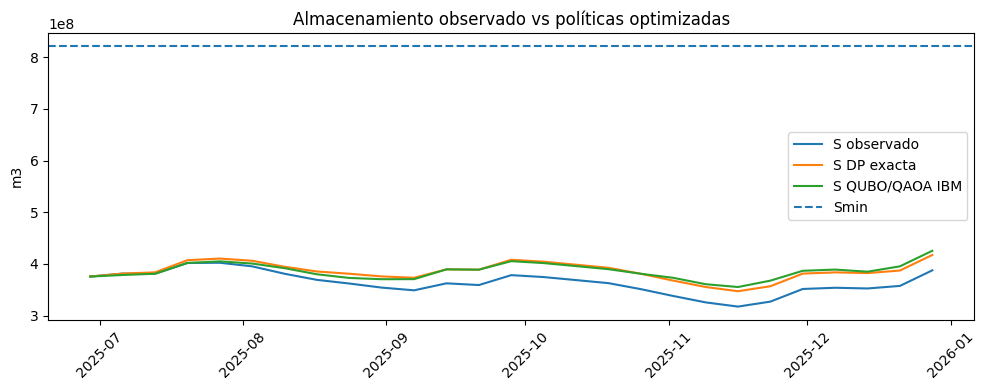

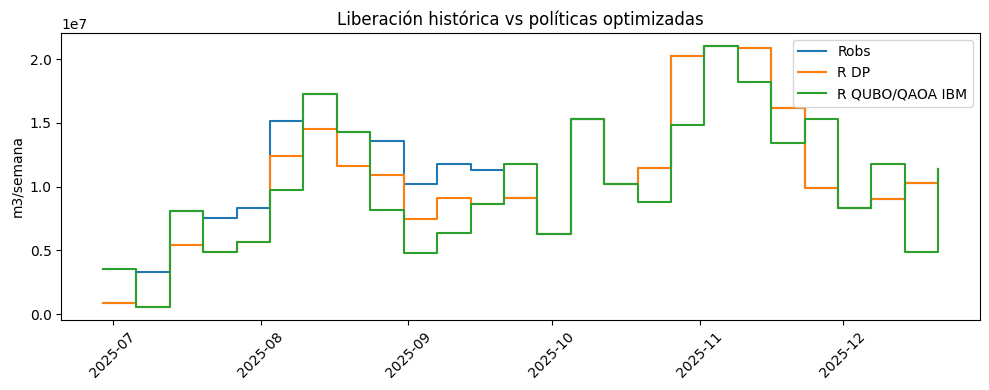

In [68]:
S_dp = evaluate_policy(dp["u"], Robs, Sobs, S_MIN, S_MAX)["Sopt"]
S_q = evaluate_policy(u_ibm_like, Robs, Sobs, S_MIN, S_MAX)["Sopt"]

plt.figure(figsize=(10,4))
plt.plot(dates, Sobs, label="S observado")
plt.plot(dates, S_dp, label="S DP exacta")
plt.plot(dates, S_q, label="S QUBO/QAOA IBM")
plt.axhline(S_MIN, linestyle="--", label="Smin")
plt.title("Almacenamiento observado vs políticas optimizadas")
plt.ylabel("m3")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.step(dates[:T_OFFICIAL], Robs, where="post", label="Robs")
plt.step(dates[:T_OFFICIAL], Robs + dp["u"], where="post", label="R DP")
plt.step(dates[:T_OFFICIAL], Robs + u_ibm_like, where="post", label="R QUBO/QAOA IBM")
plt.title("Liberación histórica vs políticas optimizadas")
plt.ylabel("m3/semana")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 15. Recomendaciones de ejecución en IBM

Para presentar resultados finales en IBM Qiskit:

1. Correr primero con `EXECUTE_IBM=False` para validar datos, DP y QUBO.
2. Confirmar que el bloque máximo usa `28` qubits.
3. Activar `EXECUTE_IBM=True`.
4. Guardar el `job_id` de IBM Runtime.
5. Revisar si el orden de bitstrings requiere `reverse_bit_order=True`.
6. Comparar la política reconstruida contra DP exacta con `final_df`.

### Ajustes útiles

- Si el circuito queda muy profundo, reducir `BLOCK_SIZE=5` para usar 20 qubits por bloque.
- Si el QPU tiene ruido alto, aumentar shots a `4096` o `8192`.
- Si se quiere optimizar parámetros QAOA, ejecutar varios pares `(gamma,beta)` y seleccionar el menor QUBO esperado por bloque.
- Para presentación, reportar DP como óptimo discreto clásico y QAOA/IBM como escalamiento cuántico factible bajo 30 qubits.